<h1 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #1f2937 45%, #334155 100%);
  padding: 16px 20px;
  border-radius: 14px;
  text-align: center;
  box-shadow: 0 12px 30px rgba(0,0,0,.20);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 6px solid #38bdf8;
  margin: 0;
">
  EDA del dataset de diabetes
</h1>

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
">
Carga de librerias y lectura del dataset
</h2>

In [ ]:
import warnings
warnings.filterwarnings("ignore")
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from sklearn.model_selection import train_test_split
pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
">
Lectura del dataset
</h2>

In [3]:
df = pd.read_csv("../data/raw/diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


<div style="
  background: #ececec;
  border-left: 6px solid #22c55e;
  border-radius: 12px;
  padding: 16px 18px;
  box-shadow: 0 8px 24px rgba(15,23,42,.08);
  margin: 6px 0 2px 0;
">
  <p style="margin: 0 0 10px 0; line-height: 1.75; color: #111827; font-size: 16px;"><span style="color: #ef4444; font-weight: 700;">Pregnancies</span>: numero de embarazos.</p>
  <p style="margin: 0 0 10px 0; line-height: 1.75; color: #111827; font-size: 16px;"><span style="color: #ef4444; font-weight: 700;">Glucose</span>: concentracion de glucosa en plasma.</p>
  <p style="margin: 0 0 10px 0; line-height: 1.75; color: #111827; font-size: 16px;"><span style="color: #ef4444; font-weight: 700;">BloodPressure</span>: presion arterial diastolica.</p>
  <p style="margin: 0 0 10px 0; line-height: 1.75; color: #111827; font-size: 16px;"><span style="color: #ef4444; font-weight: 700;">SkinThickness</span>: grosor del pliegue cutaneo del triceps.</p>
  <p style="margin: 0 0 10px 0; line-height: 1.75; color: #111827; font-size: 16px;"><span style="color: #ef4444; font-weight: 700;">Insulin</span>: nivel de insulina serica.</p>
  <p style="margin: 0 0 10px 0; line-height: 1.75; color: #111827; font-size: 16px;"><span style="color: #ef4444; font-weight: 700;">BMI</span>: indice de masa corporal.</p>
  <p style="margin: 0 0 10px 0; line-height: 1.75; color: #111827; font-size: 16px;"><span style="color: #ef4444; font-weight: 700;">DiabetesPedigreeFunction</span>: indicador relacionado con antecedentes familiares de diabetes.</p>
  <p style="margin: 0 0 10px 0; line-height: 1.75; color: #111827; font-size: 16px;"><span style="color: #ef4444; font-weight: 700;">Age</span>: edad del paciente.</p>
  <p style="margin: 0; line-height: 1.75; color: #111827; font-size: 16px;"><span style="color: #ef4444; font-weight: 700;">Outcome</span>: variable objetivo; 0 indica no diabetes y 1 indica diabetes.</p>
</div>

<h4 style="
  color: #ffffff;
  background: linear-gradient(135deg, #1f2937 0%, #111827 100%);
  padding: 10px 14px;
  border-radius: 8px;
  border-left: 5px solid #38bdf8;
  margin: 0;
">
Dimensiones, filas y columnas del dataset
</h4>

In [4]:
print("Shape del dataset:", df.shape)
print("Columnas:", df.columns.tolist())

Shape del dataset: (768, 9)
Columnas: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']


<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
">
Inspeccion inicial y calidad de datos
</h2>

<h4 style="
  color: #ffffff;
  background: linear-gradient(135deg, #1f2937 0%, #111827 100%);
  padding: 10px 14px;
  border-radius: 8px;
  border-left: 5px solid #38bdf8;
  margin: 0;
">
Resumen rapido del dataset
</h4>

In [5]:
print("Dimensiones del dataset:", df.shape)

print("\nValores nulos por columna:")
display(df.isnull().sum().to_frame("null_count"))

print("\nFilas duplicadas:", df.duplicated().sum())

Dimensiones del dataset: (768, 9)

Valores nulos por columna:


,null_count
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0



Filas duplicadas: 0


<h4 style="
  color: #ffffff;
  background: linear-gradient(135deg, #1f2937 0%, #111827 100%);
  padding: 10px 14px;
  border-radius: 8px;
  border-left: 5px solid #38bdf8;
  margin: 0;
">
Informacion general de columnas
</h4>

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


<h4 style="
  color: #ffffff;
  background: linear-gradient(135deg, #1f2937 0%, #111827 100%);
  padding: 10px 14px;
  border-radius: 8px;
  border-left: 5px solid #38bdf8;
  margin: 0;
">
Estadistica descriptiva inicial
</h4>

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
">
Revision de ceros sospechosos
</h2>

<div style="
  font-size: 20px;
  line-height: 1.7;
  color: #1f2937;
  background-color: #f8fafc;
  border-left: 6px solid #38bdf8;
  padding: 16px 18px;
  border-radius: 10px;
">
He notado que el dataset no muestra valores nulos de forma directa, en este tipo de datos medicos algunos ceros pueden ser sospechosos. Por ejemplo, un valor de glucosa, presion arterial o indice de masa corporal igual a cero podria no representar un valor real, sino un dato faltante registrado de forma incorrecta.
</div>

In [8]:
zero_cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

zero_counts = pd.DataFrame({
    "zero_count": (df[zero_cols] == 0).sum(),
    "zero_pct": ((df[zero_cols] == 0).mean() * 100).round(2)
}).sort_values("zero_count", ascending=False)

zero_counts

,zero_count,zero_pct
Insulin,374,48.70
SkinThickness,227,29.56
BloodPressure,35,4.56
BMI,11,1.43
Glucose,5,0.65


<div style="
  background: #ececec;
  border-left: 6px solid #22c55e;
  border-radius: 12px;
  padding: 16px 18px;
  box-shadow: 0 8px 24px rgba(15,23,42,.08);
  margin: 6px 0 2px 0;
">
  <p style="margin: 0 0 12px 0; line-height: 1.75; color: #111827; font-size: 16px;">
    La revision muestra que varias variables medicas contienen valores iguales a <span style="color: #ef4444; font-weight: 700;">0</span> en una proporcion relevante. Esto llama especialmente la atencion en <span style="color: #ef4444; font-weight: 700;">Insulin</span> y <span style="color: #ef4444; font-weight: 700;">SkinThickness</span>, donde la cantidad de ceros es muy alta. En terminos practicos, estos valores pueden estar representando datos faltantes y no mediciones reales, por lo que mas adelante habra que tratarlos con cuidado.
  </p>
</div>

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
">
Distribucion de la variable objetivo
</h2>

<div style="
  font-size: 20px;
  line-height: 1.7;
  color: #1f2937;
  background-color: #f8fafc;
  border-left: 6px solid #38bdf8;
  padding: 16px 18px;
  border-radius: 10px;
">
Ahora analizamos la variable objetivo <b>Outcome</b> para ver cuántos pacientes pertenecen a cada clase. Esto nos permite saber si el dataset esta equilibrado o si una clase aparece con mucha mas frecuencia que la otra.
</div>

In [9]:
outcome_counts = df["Outcome"].value_counts().sort_index()
outcome_pct = df["Outcome"].value_counts(normalize=True).sort_index().mul(100).round(2)

display(pd.DataFrame({
    "count": outcome_counts,
    "pct": outcome_pct
}))

,count,pct
Outcome,,
0,500,65.1
1,268,34.9


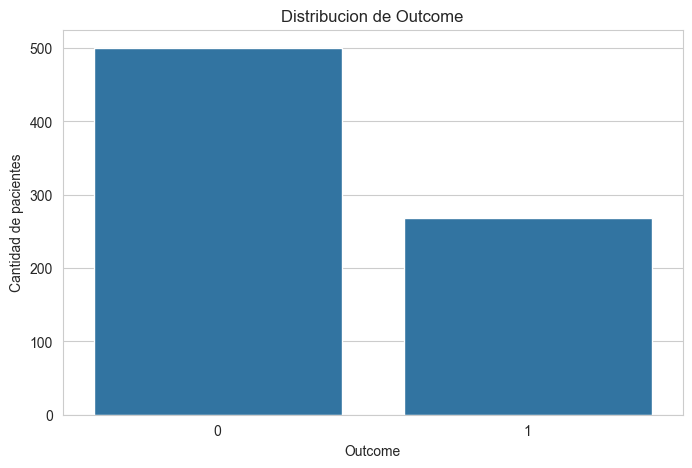

In [10]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="Outcome")
plt.title("Distribucion de Outcome")
plt.xlabel("Outcome")
plt.ylabel("Cantidad de pacientes")
plt.show()

<div style="
  background: #ececec;
  border-left: 6px solid #22c55e;
  border-radius: 12px;
  padding: 16px 18px;
  box-shadow: 0 8px 24px rgba(15,23,42,.08);
  margin: 6px 0 2px 0;
">
  <p style="margin: 0 0 12px 0; line-height: 1.75; color: #111827; font-size: 16px;">
    La variable <span style="color: #ef4444; font-weight: 700;">Outcome</span> muestra que hay mas pacientes sin diabetes que con diabetes. Aunque el desbalance no es extremo, si existe una diferencia entre ambas clases, por lo que mas adelante convendra revisar no solo <span style="color: #ef4444; font-weight: 700;">accuracy</span>, sino tambien metricas como <span style="color: #ef4444; font-weight: 700;">precision</span>, <span style="color: #ef4444; font-weight: 700;">recall</span> y <span style="color: #ef4444; font-weight: 700;">F1-score</span>.
  </p>
</div>

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
">
Distribucion de las variables numericas
</h2>

<div style="
  font-size: 20px;
  line-height: 1.7;
  color: #1f2937;
  background-color: #f8fafc;
  border-left: 6px solid #38bdf8;
  padding: 16px 18px;
  border-radius: 10px;
">
En esta seccion observamos la distribucion de cada variable numerica de forma individual. Esto permite detectar variables sesgadas, concentraciones de valores en cero y posibles valores atipicos que luego pueden influir en el modelo.
</div>

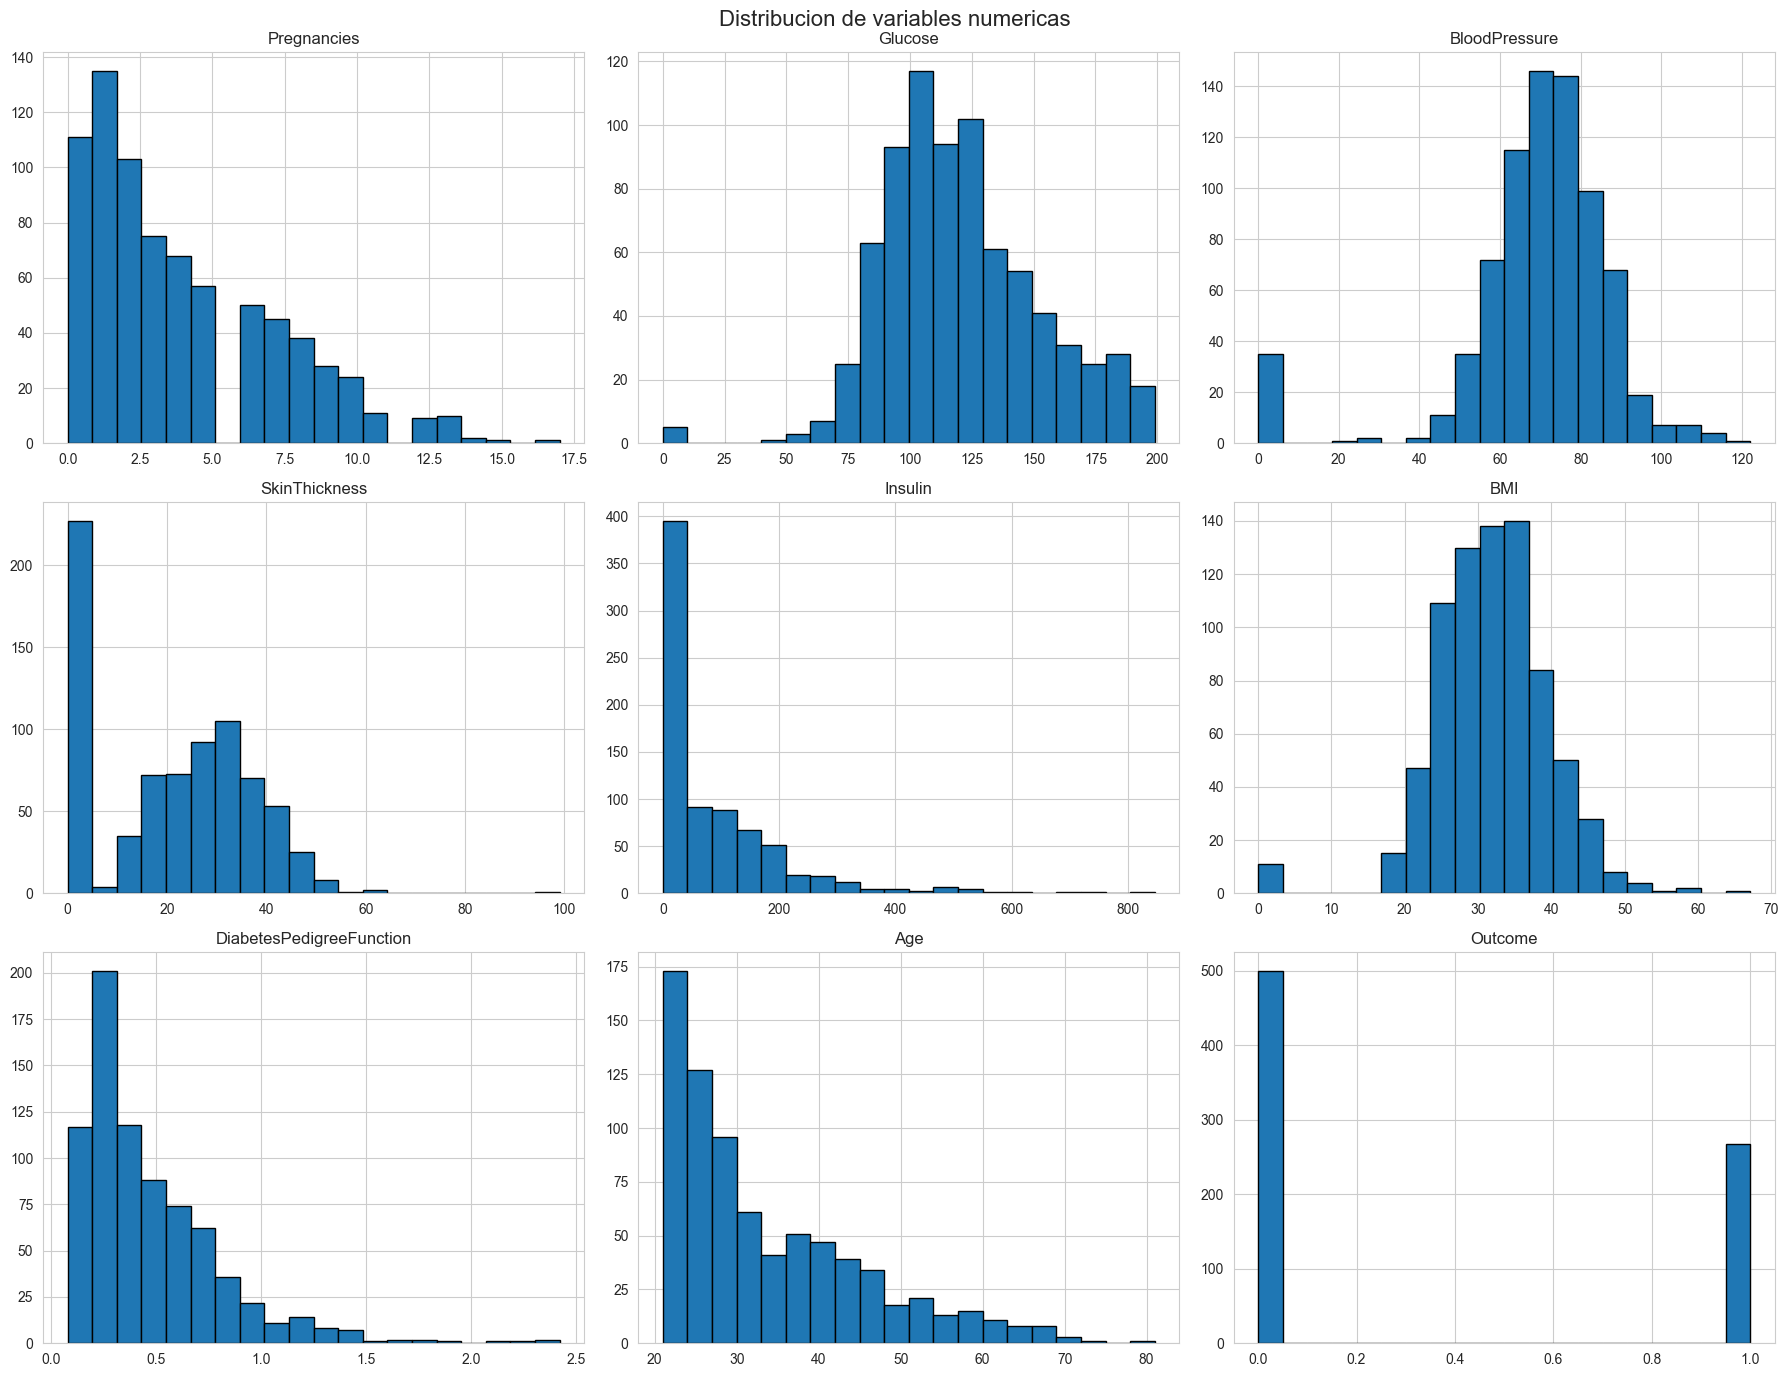

In [11]:
numeric_cols = df.select_dtypes(include=["number"]).columns.tolist()

df[numeric_cols].hist(figsize=(18, 14), bins=20, edgecolor="black")
plt.suptitle("Distribucion de variables numericas", fontsize=16)
plt.tight_layout()
plt.show()

<div style="
  background: #ececec;
  border-left: 6px solid #22c55e;
  border-radius: 12px;
  padding: 16px 18px;
  box-shadow: 0 8px 24px rgba(15,23,42,.08);
  margin: 6px 0 2px 0;
">
  <p style="margin: 0 0 12px 0; line-height: 1.75; color: #111827; font-size: 16px;">
    La distribucion de las variables numericas muestra que no todas siguen un patron equilibrado. Algunas, como <span style="color: #ef4444; font-weight: 700;">Insulin</span> y <span style="color: #ef4444; font-weight: 700;">SkinThickness</span>, presentan una concentracion muy fuerte en valores bajos o en cero, lo que refuerza la idea de que pueden existir datos faltantes disfrazados. Otras variables como <span style="color: #ef4444; font-weight: 700;">Glucose</span>, <span style="color: #ef4444; font-weight: 700;">BMI</span> y <span style="color: #ef4444; font-weight: 700;">Age</span> muestran formas mas utiles para el analisis y probablemente tendran mas peso en la prediccion.
  </p>
</div>

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
">
Boxplots de las variables numericas
</h2>

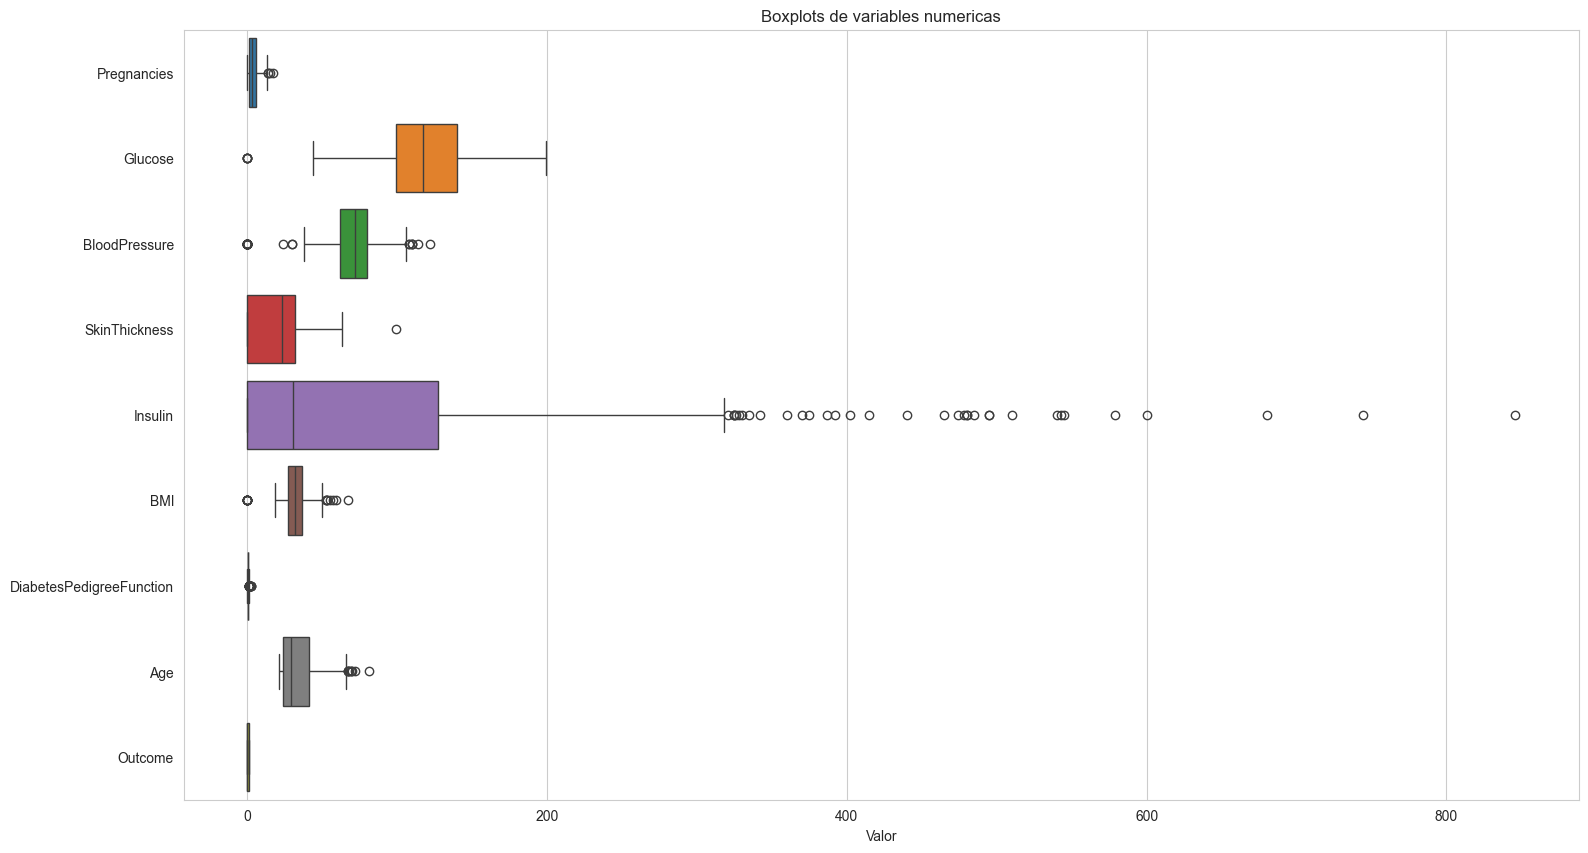

In [12]:
plt.figure(figsize=(18, 10))
sns.boxplot(data=df[numeric_cols], orient="h")
plt.title("Boxplots de variables numericas")
plt.xlabel("Valor")
plt.show()

<div style="
  background: #ececec;
  border-left: 6px solid #22c55e;
  border-radius: 12px;
  padding: 16px 18px;
  box-shadow: 0 8px 24px rgba(15,23,42,.08);
  margin: 6px 0 2px 0;
">
  <p style="margin: 0 0 12px 0; line-height: 1.75; color: #111827; font-size: 16px;">
    Los boxplots confirman que varias variables presentan valores atipicos o una dispersion importante. Esto se nota especialmente en <span style="color: #ef4444; font-weight: 700;">Insulin</span>, <span style="color: #ef4444; font-weight: 700;">DiabetesPedigreeFunction</span>, <span style="color: #ef4444; font-weight: 700;">Age</span> y <span style="color: #ef4444; font-weight: 700;">Pregnancies</span>. En un contexto medico esto no significa automaticamente que debamos eliminar esos valores, pero si conviene tenerlos presentes porque pueden influir en el comportamiento del modelo.
  </p>
</div>

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
">
Relacion de las variables numericas con Outcome
</h2>

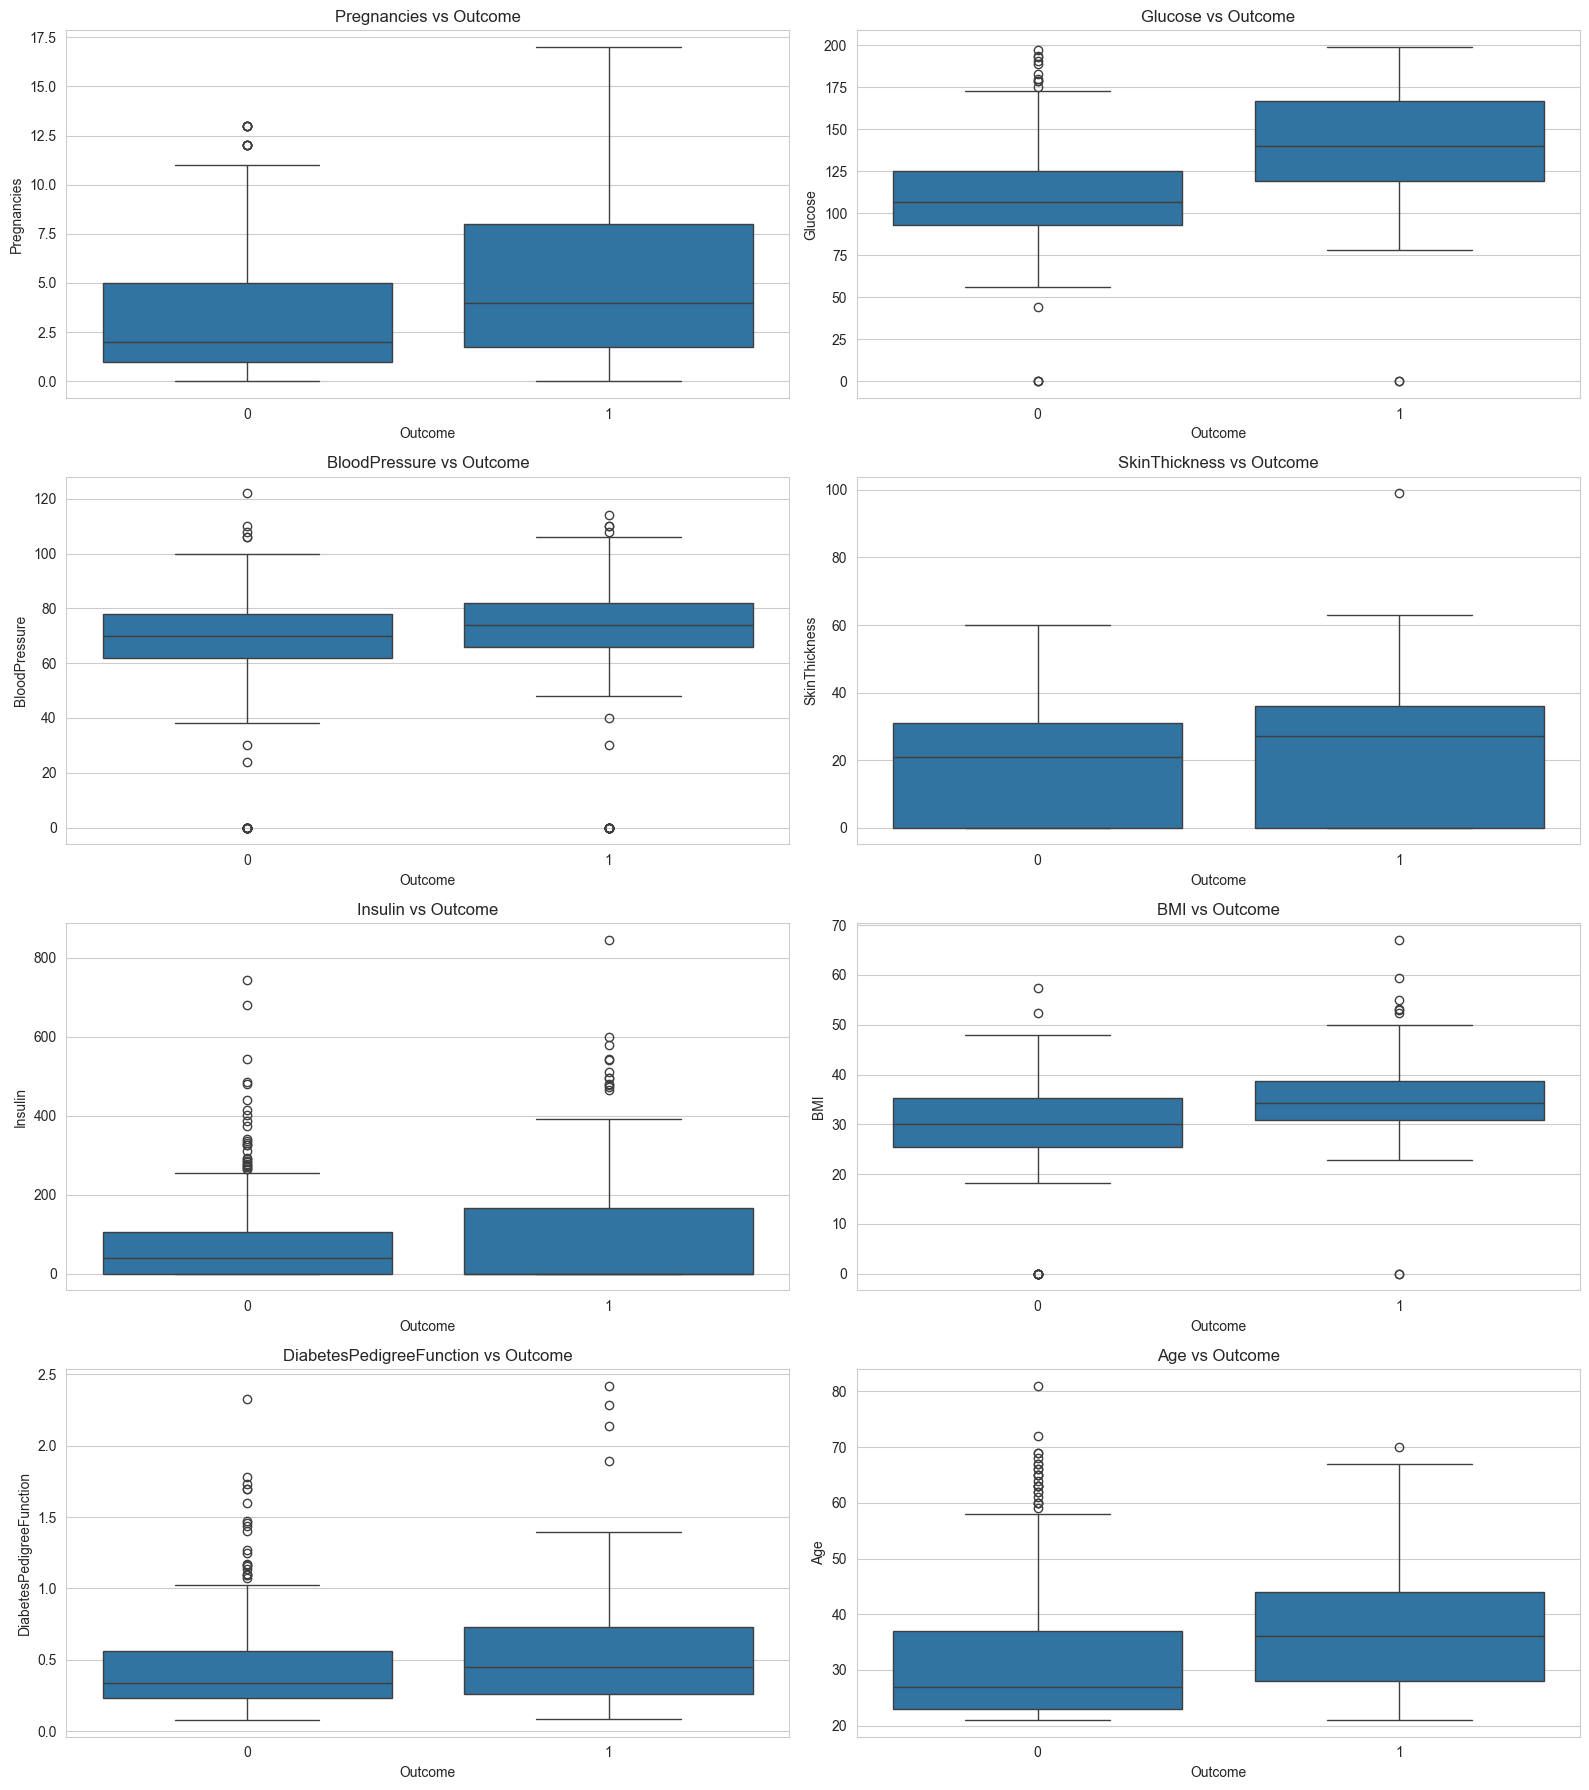

In [13]:
feature_cols = [col for col in numeric_cols if col != "Outcome"]

fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(16, 18))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    sns.boxplot(data=df, x="Outcome", y=col, ax=axes[i])
    axes[i].set_title(f"{col} vs Outcome")
    axes[i].set_xlabel("Outcome")
    axes[i].set_ylabel(col)

plt.tight_layout()
plt.show()

<div style="
  background: #ececec;
  border-left: 6px solid #22c55e;
  border-radius: 12px;
  padding: 16px 18px;
  box-shadow: 0 8px 24px rgba(15,23,42,.08);
  margin: 6px 0 2px 0;
">
  <p style="margin: 0 0 12px 0; line-height: 1.75; color: #111827; font-size: 16px;">
    Al comparar las variables con <span style="color: #ef4444; font-weight: 700;">Outcome</span>, se observa que algunas separan mejor ambas clases que otras. En especial, <span style="color: #ef4444; font-weight: 700;">Glucose</span>, <span style="color: #ef4444; font-weight: 700;">BMI</span>, <span style="color: #ef4444; font-weight: 700;">Age</span> y <span style="color: #ef4444; font-weight: 700;">Pregnancies</span> tienden a mostrar valores mas altos en pacientes con diabetes. Esto sugiere que estas variables pueden aportar informacion importante al modelo de clasificacion.
  </p>
</div>

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
">
Correlacion de las variables con Outcome
</h2>

<div style="
  font-size: 20px;
  line-height: 1.7;
  color: #1f2937;
  background-color: #f8fafc;
  border-left: 6px solid #38bdf8;
  padding: 16px 18px;
  border-radius: 10px;
">
En lugar de mostrar una matriz gigante dificil de leer, selecciono las variables numericas con mayor relacion lineal con la variable objetivo. Asi la lectura resulta mas clara.
</div>

In [14]:
corr_outcome = (
    df.corr(numeric_only=True)["Outcome"]
    .drop("Outcome")
    .sort_values(ascending=False)
    .to_frame("correlation_with_outcome")
)

corr_outcome

,correlation_with_outcome
Glucose,0.466581
BMI,0.292695
Age,0.238356
Pregnancies,0.221898
DiabetesPedigreeFunction,0.173844
Insulin,0.130548
SkinThickness,0.074752
BloodPressure,0.065068


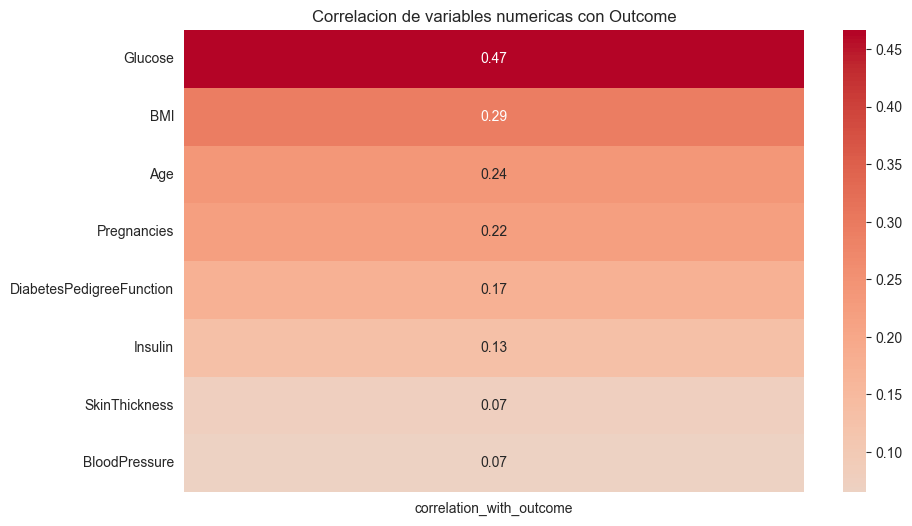

In [15]:
plt.figure(figsize=(10, 6))
sns.heatmap(
    corr_outcome,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f"
)
plt.title("Correlacion de variables numericas con Outcome")
plt.show()

<div style="
  background: #ececec;
  border-left: 6px solid #22c55e;
  border-radius: 12px;
  padding: 16px 18px;
  box-shadow: 0 8px 24px rgba(15,23,42,.08);
  margin: 6px 0 2px 0;
">
  <p style="margin: 0 0 12px 0; line-height: 1.75; color: #111827; font-size: 16px;">La relacion lineal mas alta con <span style="color: #ef4444; font-weight: 700;">Outcome</span> aparece en <span style="color: #ef4444; font-weight: 700;">Glucose</span>, seguida por <span style="color: #ef4444; font-weight: 700;">BMI</span>, <span style="color: #ef4444; font-weight: 700;">Age</span> y <span style="color: #ef4444; font-weight: 700;">Pregnancies</span>. En lenguaje simple, esto sugiere que estas variables estan mas asociadas con la presencia de diabetes que el resto. Aun asi, una correlacion baja no significa que una variable no sirva, especialmente en modelos como los arboles de decision, que pueden captar relaciones no lineales.</p>
</div>

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
">
Tratamiento de ceros sospechosos
</h2>

<div style="
  font-size: 20px;
  line-height: 1.7;
  color: #1f2937;
  background-color: #f8fafc;
  border-left: 6px solid #38bdf8;
  padding: 16px 18px;
  border-radius: 10px;
">
En varias variables medicas el valor cero no parece representar una medicion real. Por eso, en esta etapa reemplazo esos ceros por <b>NaN</b> para tratarlos como valores faltantes. De esta manera evitamos que el modelo interprete esos ceros como datos validos cuando en realidad pueden ser registros incompletos.
</div>

In [16]:
df_clean = df.copy()

zero_as_nan_cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

df_clean[zero_as_nan_cols] = df_clean[zero_as_nan_cols].replace(0, np.nan)

df_clean[zero_as_nan_cols].isnull().sum().to_frame("null_count_after_replacement")

,null_count_after_replacement
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11


<div style="
  background: #ececec;
  border-left: 6px solid #22c55e;
  border-radius: 12px;
  padding: 16px 18px;
  box-shadow: 0 8px 24px rgba(15,23,42,.08);
  margin: 6px 0 2px 0;
">
  <p style="margin: 0 0 12px 0; line-height: 1.75; color: #111827; font-size: 16px;">Con este cambio, varias columnas pasan a mostrar valores faltantes de forma explicita. Esto es mas correcto que mantener ceros sospechosos, porque permite tratarlos despues con una estrategia de imputacion. Asi dejamos preparado el dataset para el modelado.</p>
</div>

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
">
Revision de valores faltantes
</h2>

<div style="
  font-size: 20px;
  line-height: 1.7;
  color: #1f2937;
  background-color: #f8fafc;
  border-left: 6px solid #38bdf8;
  padding: 16px 18px;
  border-radius: 10px;
">
Despues de reemplazar los ceros sospechosos por <b>NaN</b>, reviso cuántos valores faltantes quedaron en cada columna. Esto me permite dimensionar mejor el problema y preparar la estrategia de imputacion que usaremos mas adelante.
</div>

In [17]:
missing_summary = pd.DataFrame({
    "null_count": df_clean.isnull().sum(),
    "null_pct": (df_clean.isnull().mean() * 100).round(2)
}).sort_values("null_count", ascending=False)

missing_summary

,null_count,null_pct
Insulin,374,48.70
SkinThickness,227,29.56
BloodPressure,35,4.56
BMI,11,1.43
Glucose,5,0.65
Pregnancies,0,0.00
DiabetesPedigreeFunction,0,0.00
Age,0,0.00
Outcome,0,0.00


<div style="
  background: #ececec;
  border-left: 6px solid #22c55e;
  border-radius: 12px;
  padding: 16px 18px;
  box-shadow: 0 8px 24px rgba(15,23,42,.08);
  margin: 6px 0 2px 0;
">
  <p style="margin: 0 0 12px 0; line-height: 1.75; color: #111827; font-size: 16px;">La revision confirma que el mayor problema de datos faltantes aparece en <span style="color: #ef4444; font-weight: 700;">Insulin</span> y <span style="color: #ef4444; font-weight: 700;">SkinThickness</span>. Esto refuerza la idea de que el dataset venia sin nulos visibles, pero con una parte importante de valores dudosos codificados como cero. Ahora ya tenemos ese problema identificado de forma clara y lista para tratarlo correctamente.</p>
</div>

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
">
Imputacion de valores faltantes
</h2>


<div style="
  font-size: 20px;
  line-height: 1.7;
  color: #1f2937;
  background-color: #f8fafc;
  border-left: 6px solid #38bdf8;
  padding: 16px 18px;
  border-radius: 10px;
">
Para completar los valores faltantes uso la <b>mediana</b> de cada columna. Esta decision es adecuada porque varias variables presentan asimetria y valores extremos, por lo que la mediana suele ser una referencia mas estable que la media.
</div>

In [19]:
df_ready = df_clean.copy()

for col in zero_as_nan_cols:
    df_ready[col] = df_ready[col].fillna(df_ready[col].median())

df_ready.isnull().sum().to_frame("null_count_after_imputation")

,null_count_after_imputation
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


<div style="
  background: #ececec;
  border-left: 6px solid #22c55e;
  border-radius: 12px;
  padding: 16px 18px;
  box-shadow: 0 8px 24px rgba(15,23,42,.08);
  margin: 6px 0 2px 0;
">
  <p style="margin: 0 0 12px 0; line-height: 1.75; color: #111827; font-size: 16px;">Despues de la imputacion, el dataset queda sin valores faltantes en las columnas tratadas. En terminos practicos, esto significa que ya tenemos una version mas utilizable del conjunto de datos, manteniendo la estructura original pero corrigiendo el problema de los ceros sospechosos.</p>
</div>

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
">
Separacion de variables predictoras y variable objetivo
</h2>

<div style="
  font-size: 20px;
  line-height: 1.7;
  color: #1f2937;
  background-color: #f8fafc;
  border-left: 6px solid #38bdf8;
  padding: 16px 18px;
  border-radius: 10px;
">
En esta etapa separo las variables que usara el modelo para aprender de la variable que queremos predecir. Las columnas explicativas quedaran en <b>X</b> y la columna objetivo <b>Outcome</b> quedara en <b>y</b>.
</div>

In [20]:
X = df_ready.drop(columns="Outcome")
y = df_ready["Outcome"]

print("Shape de X:", X.shape)
print("Shape de y:", y.shape)

Shape de X: (768, 8)
Shape de y: (768,)


<div style="
  background: #ececec;
  border-left: 6px solid #22c55e;
  border-radius: 12px;
  padding: 16px 18px;
  box-shadow: 0 8px 24px rgba(15,23,42,.08);
  margin: 6px 0 2px 0;
">
  <p style="margin: 0 0 12px 0; line-height: 1.75; color: #111827; font-size: 16px;">La separacion deja por un lado las variables predictoras y por otro la variable objetivo. Esto es importante porque el modelo debe aprender a predecir <span style="color: #ef4444; font-weight: 700;">Outcome</span> a partir del resto de columnas, sin usar la propia respuesta dentro de los datos de entrada.</p>
</div>

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
">
Division en entrenamiento y prueba
</h2>

<div style="
  font-size: 20px;
  line-height: 1.7;
  color: #1f2937;
  background-color: #f8fafc;
  border-left: 6px solid #38bdf8;
  padding: 16px 18px;
  border-radius: 10px;
">
Ahora divido los datos en dos partes: una para entrenar el modelo y otra para evaluarlo. Uso una separacion 80/20 y aplico <b>stratify</b> sobre la variable objetivo para conservar la proporcion de clases en ambos grupos.
</div>

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Shape de X_train:", X_train.shape)
print("Shape de X_test:", X_test.shape)
print("Shape de y_train:", y_train.shape)
print("Shape de y_test:", y_test.shape)

Shape de X_train: (614, 8)
Shape de X_test: (154, 8)
Shape de y_train: (614,)
Shape de y_test: (154,)


<div style="
  background: #ececec;
  border-left: 6px solid #22c55e;
  border-radius: 12px;
  padding: 16px 18px;
  box-shadow: 0 8px 24px rgba(15,23,42,.08);
  margin: 6px 0 2px 0;
">
  <p style="margin: 0 0 12px 0; line-height: 1.75; color: #111827; font-size: 16px;">Con esta division, el modelo aprendera usando solo el conjunto de entrenamiento y sera evaluado con datos que no vio antes. El uso de <span style="color: #ef4444; font-weight: 700;">stratify</span> ayuda a mantener una proporcion similar de pacientes con y sin diabetes en train y test, lo que hace la evaluacion mas justa y estable.</p>
</div>

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
">
Guardado de datos preparados
</h2>

<div style="
  font-size: 20px;
  line-height: 1.7;
  color: #1f2937;
  background-color: #f8fafc;
  border-left: 6px solid #38bdf8;
  padding: 16px 18px;
  border-radius: 10px;
">
Como este analisis exploratorio servira de base para varios modelos, guardo una version ya preparada del dataset y tambien los conjuntos de entrenamiento y prueba. Asi puedo reutilizar los datos sin repetir todo el proceso de limpieza en cada notebook futuro.
</div>

In [ ]:
processed_path = "../data/processed/diabetes_decision_tree"
os.makedirs(processed_path, exist_ok=True)

df_ready.to_csv(f"{processed_path}/diabetes_ready.csv", index=False)

X_train.to_csv(f"{processed_path}/X_train.csv", index=False)
X_test.to_csv(f"{processed_path}/X_test.csv", index=False)
y_train.to_frame(name="Outcome").to_csv(f"{processed_path}/y_train.csv", index=False)
y_test.to_frame(name="Outcome").to_csv(f"{processed_path}/y_test.csv", index=False)

print("Archivos guardados correctamente en ../data/processed/diabetes_decision_tree")

Archivos guardados correctamente en ../data/processed/diabetes_decision_tree
